# Data Preprocessing & Input Pipeline Preparation

### 🎯 Goal of This Notebook
<pre>
The goal of this notebook is to preprocess crop leaf images and build efficient, Keras-compatible input pipelines
for training, validation, and testing of CNN models.
</pre>
### This notebook ensures:
 - All images are uniformly resized and normalized
 - Data augmentation is applied correctly (train only)
 - Class labels are encoded properly
 - Data loaders are optimized for performance and memory usage


## Clone the GitHub Repository
### 📌 Purpose
<pre>
 - To obtain the complete project structure locally for exploration and experimentation.
</pre>

In [1]:
# Clone the Repository
!git clone https://github.com/sabin74/Agriculture-Crop-Disease-Detection-Advisory-System.git


Cloning into 'Agriculture-Crop-Disease-Detection-Advisory-System'...
remote: Enumerating objects: 97108, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 97108 (delta 4), reused 3 (delta 3), pack-reused 97089 (from 2)
Receiving objects: 100% (97108/97108), 1.56 GiB | 7.84 MiB/s, done.
Resolving deltas: 100% (449/449), done.
Updating files: 100% (94781/94781), done.


In [2]:
# Set Project Root
import os
os.chdir("/content/Agriculture-Crop-Disease-Detection-Advisory-System")
print("Current Directory: ", os.getcwd())

Current Directory:  /content/Agriculture-Crop-Disease-Detection-Advisory-System


## Import Required Libraries
### 📌 Purpose

Load all libraries required for image preprocessing, input pipeline preparation, augmentation, and sanity checks.

In [3]:
# System & Path Handling
import os
from pathlib import Path

# Numerical
import numpy as np

# TensorFlow / Keras
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Visualization (Sanity checks)
import matplotlib.pyplot as plt

# Config saving
import json
import yaml

In [4]:
# Environment Verification
print("TensorFlow Version: ", tf.__version__)
print("Keras Version: ", keras.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version:  2.19.0
Keras Version:  3.10.0
GPU Available: []


##Define Dataset Paths
### 📌 Purpose

Centralize all dataset directory paths in one place so they can be reused consistently throughout the notebook.

In [5]:
# Define Dataset Root Directory
DATASET_ROOT = Path("Modeling/Crop Disease Dataset")

#Define Individual Dataset Split
TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"
VALID_DIR = DATASET_ROOT / "valid"

# Display Path
print(f"Train Directory: {TRAIN_DIR}")
print(f"Test Directory: {TEST_DIR}")
print(f"Valid Directory: {VALID_DIR}")

Train Directory: Modeling/Crop Disease Dataset/train
Test Directory: Modeling/Crop Disease Dataset/test
Valid Directory: Modeling/Crop Disease Dataset/valid


## Define Image Parameters
### 📌 Purpose

Standardize image inputs so all CNN models receive uniform data, ensuring:

 - Consistent tensor shapes
 - Model compatibility
 - Stable training behavior

In [6]:
# Image Parameter
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
COLOR_MODE = 'rgb'

## Data Augmentation Strategy
### 📌 Purpose

Increase data diversity and model generalization by applying realistic transformations only to training images.

In [7]:
# Training Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode="nearest"
)

In [8]:
# Validation and Test Data
valid_test_datagen = ImageDataGenerator(
    rescale=1./255
)

## Create Training Data Generator
### 📌 Purpose

Load training images dynamically from disk, apply data augmentation, and generate:

 - Image batches
 - One-hot encoded class labels

In [9]:
# Training Data Generator
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    class_mode="categorical",
    shuffle=True
)

Found 74880 images belonging to 13 classes.


In [10]:
print("Number of Classes:", train_generator.num_classes)
print("Class Indices:")
train_generator.class_indices

Number of Classes: 13
Class Indices:


{'apple': 0,
 'banana': 1,
 'cherry': 2,
 'coffee': 3,
 'corn': 4,
 'grape': 5,
 'mango': 6,
 'orange': 7,
 'peach': 8,
 'potato': 9,
 'strawberry': 10,
 'sugarcane': 11,
 'tomato': 12}

## Create Validation Data Generator
###📌 Purpose

Provide unbiased evaluation data during training by:

 - Applying no augmentation
 - Using only rescaling
 - Preserving deterministic order of samples

In [11]:
valid_generator = valid_test_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    class_mode="categorical",
    shuffle=False
)

Found 19804 images belonging to 13 classes.


## Verify Class Labels & Encoding
📌 Purpose

Ensure that class names → numeric indices mapping is Correct,
Consistent & Reusable across training, evaluation and deployment

In [12]:
class_indices = train_generator.class_indices

for k, v in class_indices.items():
    print(v, ":", k)

CONFIG_DIR = Path("Modeling/configs")
CONFIG_DIR.mkdir(exist_ok=True)

with open(CONFIG_DIR / "classes.json", "w") as f:
    json.dump(class_indices, f, indent=4)


0 : apple
1 : banana
2 : cherry
3 : coffee
4 : corn
5 : grape
6 : mango
7 : orange
8 : peach
9 : potato
10 : strawberry
11 : sugarcane
12 : tomato


## Sanity Check – Visualize Augmented Images
### 📌 Purpose

Visually confirm that:

 - Images are resized to 224×224
 - Augmentations are applied realistically
 - Labels correctly match the images

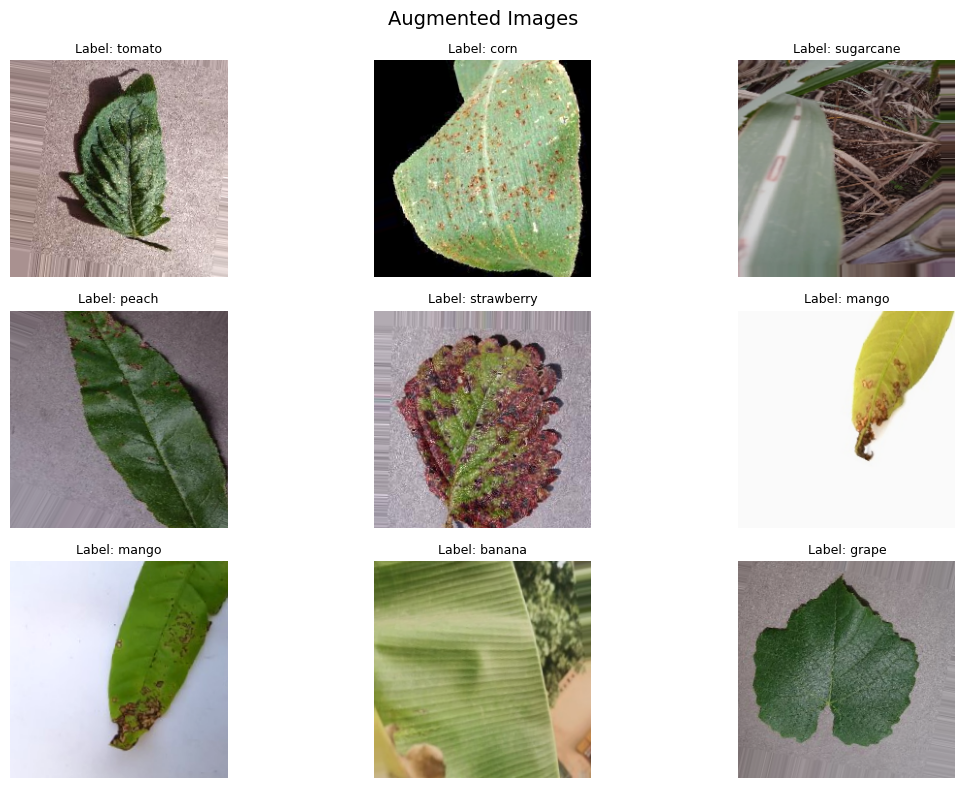

In [13]:
# fetch image
image, labels = next(train_generator)

# Reverse class_indices for lable decoding
class_names = {v: k for k, v in class_indices.items()}

# plot augmented image
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image[i])

    label_index = np.argmax(labels[i])
    label_name = class_names[label_index]
    plt.title(f"Label: {label_name}", fontsize=9)
    plt.axis('off')

plt.suptitle("Augmented Images", fontsize=14)
plt.tight_layout()
plt.show()

## Save Preprocessing and Configuration

In [14]:
config = {
    "image": {
        "size": IMAGE_SIZE,
        "color_mode": COLOR_MODE
    },
    "training": {
        "batch_size": BATCH_SIZE
    },
    "augmentation": {
        "rotation_range": 25,
        "zoom_range": 0.2,
        "horizontal_flip": True,
        "brightness_range": [0.8, 1.2],
        "width_shift_range": 0.1,
        "height_shift_range": 0.1
    },
    "num_classes": train_generator.num_classes
}

with open(CONFIG_DIR / "config.yaml", "w") as f:
    yaml.dump(config, f)
